In [1]:
import os, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.ticker as ticker
from IPython.display import HTML
import scipy.io
import csv

MovieWriter imagemagick unavailable; using Pillow instead.


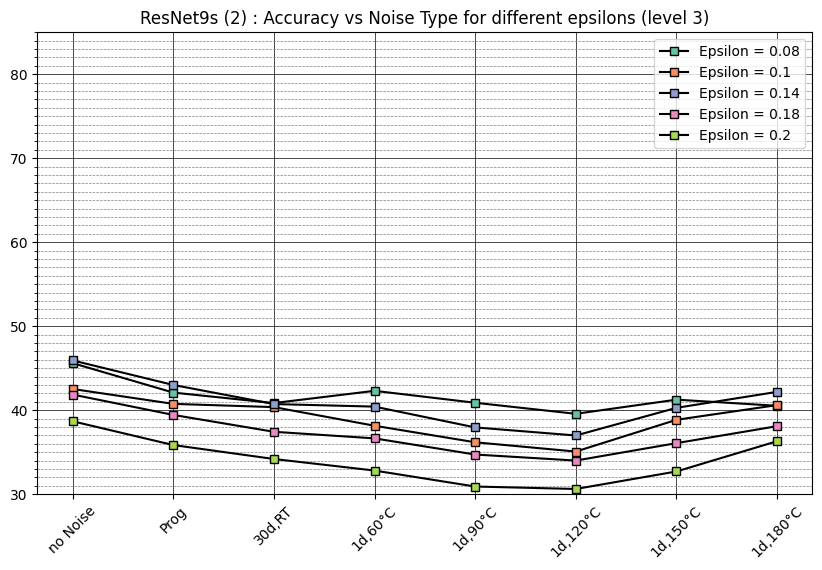

In [11]:

RESULTS = "../resnet/results/eps_comparison_gauss"
LEVELS = [3,5,9,17,33]
file_name = "accuracies_eps_resnet_{}_whole.csv"

data = data = scipy.io.loadmat('../data/matlab/4bit.mat')
noise_names = ["no Noise"] + [str(data["str"][0][i][0]) for i in range(len(data["str"][0]))]
#delete 1d, RT datapoint
noise_names.pop(2)
epsilon = [0.08, 0.10, 0.14 , 0.18, 0.20]
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Create an animation: each frame represents a level, and for each level, we plot the accuracies
# for each noise type (x axis). The different epsilons are represented by different lines with different colors

fig, ax = plt.subplots(figsize=(10,6))
smootheness= 15
steady = 40

l = LEVELS[0]
file = os.path.join(RESULTS, file_name.format(l))
res = np.loadtxt(file, delimiter=",", skiprows=1, usecols=range(1, 10))
res = np.delete(res, 2, 1)
colors = matplotlib.colormaps["Set2"].colors
lines = []
for i in range(len(res)):
    lines.append(ax.plot(res[i], label="Epsilon = {}".format(epsilon[i]), markerfacecolor = colors[i], color = "k", marker = "s"))
ax.yaxis.set_major_locator(ticker. MultipleLocator(10))
ax.yaxis.set_minor_locator(ticker. MultipleLocator(1))
ax.set_xticks(range(len(noise_names)))
ax.set_xticklabels(noise_names, rotation=45)
ax.grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
ax.grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
ax.set_ylim(30,85)
ax.legend()
ax.set_title("Accuracy vs Noise Type for different epsilons (level {})".format(l))



def update(frame, smooth= smootheness, steady = steady):
    global LEVELS, file_name, noise_names, epsilon, lines, text

    phase = frame // (smooth + steady)

    transition = frame % (smooth + steady)

    if transition < steady:
        l = LEVELS[phase]

        file = os.path.join(RESULTS, file_name.format(l))
        res = np.loadtxt(file, delimiter=",", skiprows=1, usecols=range(1, 10))
        res = np.delete(res, 2, 1)
        data = res
    else:
        l = LEVELS[phase]
        r = LEVELS[phase +1]
        file1 = os.path.join(RESULTS, file_name.format(l))
        file2 = os.path.join(RESULTS, file_name.format(r))
        res1 = np.loadtxt(file1, delimiter=",", skiprows=1, usecols=range(1, 10))
        res1 = np.delete(res1, 2, 1)
        res2 = np.loadtxt(file2, delimiter=",", skiprows=1, usecols=range(1, 10))
        res2 = np.delete(res2, 2, 1)

        # interpolate
        data = (res2 - res1) * (transition - steady) / smooth + res1

    colors = matplotlib.colormaps["Set2"].colors
    for i in range(len(data)):
        lines[i][0].set_ydata(data[i])
        lines[i][0].set_label("Epsilon = {}".format(epsilon[i]))
    ax.set_title("ResNet9s (2) : Accuracy vs Noise Type for different epsilons (level {})".format(l))
    return lines

    

ani = animation.FuncAnimation(fig, update, frames=(len(LEVELS)-1) * smootheness + len(LEVELS)*steady, repeat=True, interval = 50)
HTML(ani.to_jshtml())
ani.save("resnet9s2_accuracy_vs_noise_type_eps.gif", writer='imagemagick', fps=30)